# Likelihood and maximum likelihood estimation

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/classification/01-likelihood-and-mle.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Before fitting a logistic-regression model, let's make the central idea—**likelihood**—concrete. We will use simulated red/blue ticket draws rather than the gas-turbine dataset.

A red ticket is coded as $1$, a blue ticket as $0$, and $p$ is the unknown probability of drawing red.

In [1]:
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

## 1. One observed set of draws

Suppose that ten independent tickets are drawn, and six are red. The order is not important here; our observation is simply **6 red tickets out of 10**.

Which candidate value—$p=0.4$, $0.5$, $0.6$, or $0.8$—makes that observation most plausible?

In [2]:
n = 10
red_tickets = 6
blue_tickets = n - red_tickets

print(f"Observed draws: {red_tickets} red and {blue_tickets} blue tickets.")

Observed draws: 6 red and 4 blue tickets.


## 2. Likelihood of a proposed probability

For a candidate $p$, the probability of seeing six red tickets in ten draws is

$$
L(p) = \binom{10}{6}p^6(1-p)^4.
$$

The binomial coefficient counts the possible orderings of six red and four blue tickets. It is the same for every candidate $p$, so it does not change which candidate maximizes the likelihood.

We hold the observations fixed and vary $p$. Thus, likelihood is **not** the probability that a candidate parameter is true; it is a score for how well that candidate explains the observed data.

p = 0.4: likelihood = 0.1115
p = 0.5: likelihood = 0.2051
p = 0.6: likelihood = 0.2508
p = 0.8: likelihood = 0.0881


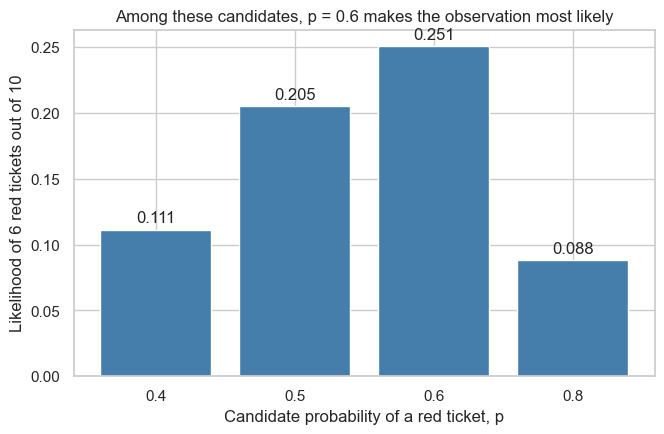

In [3]:
def likelihood(p, red_count, total_count):
    """Probability of this red-ticket count under candidate p."""
    blue_count = total_count - red_count
    return comb(total_count, red_count) * p**red_count * (1 - p)**blue_count

candidates = np.array([0.4, 0.5, 0.6, 0.8])
candidate_likelihoods = np.array([
    likelihood(p, red_tickets, n) for p in candidates
])

for p, value in zip(candidates, candidate_likelihoods):
    print(f"p = {p:.1f}: likelihood = {value:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(candidates.astype(str), candidate_likelihoods, color="#457eaa")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set(
    xlabel="Candidate probability of a red ticket, p",
    ylabel="Likelihood of 6 red tickets out of 10",
    title="Among these candidates, p = 0.6 makes the observation most likely",
)
plt.show()

## 3. Let the candidate vary continuously

Rather than considering only four candidates, let's evaluate a fine grid of values between 0 and 1. The maximum of the likelihood curve is the **maximum-likelihood estimate** (MLE):

$$
\hat p_{\mathrm{MLE}}
= \underset{p}{\operatorname{arg\,max}}\; L(p).
$$

For a Bernoulli/binomial model, the MLE is the observed red-ticket fraction, $\hat p_{\mathrm{MLE}}=6/10=0.6$.

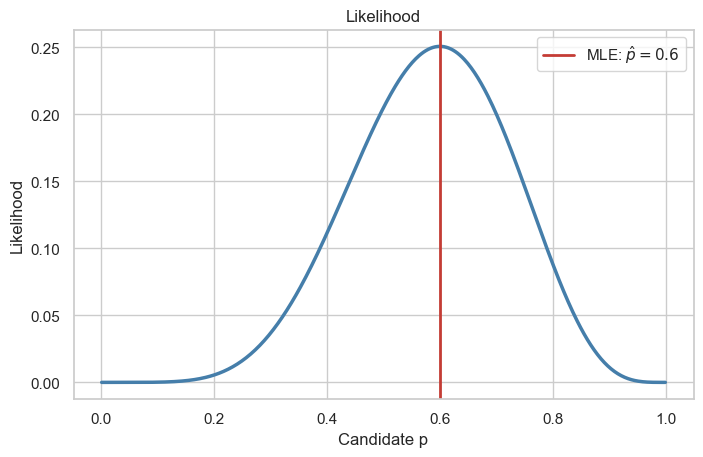

In [4]:
p_grid = np.linspace(0.001, 0.999, 500)
likelihood_grid = np.array([likelihood(p, red_tickets, n) for p in p_grid])
p_hat = red_tickets / n

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(p_grid, likelihood_grid, color="#457eaa", linewidth=2.5)
ax.axvline(p_hat, color="#c43c35", linewidth=2, label=rf"MLE: $\hat p={p_hat:.1f}$")
ax.set(
    xlabel="Candidate p",
    ylabel="Likelihood",
    title="Likelihood",
)
ax.legend()
plt.show()

## 4. More observations give more concentrated evidence

Imagine another set of 100 draws with the same observed red fraction: 60 red tickets. Both samples have $\hat p_{\mathrm{MLE}}=0.6$, but the larger sample supplies more evidence about plausible values of $p$. The two panels use their own vertical scales so that both likelihood curves remain readable.

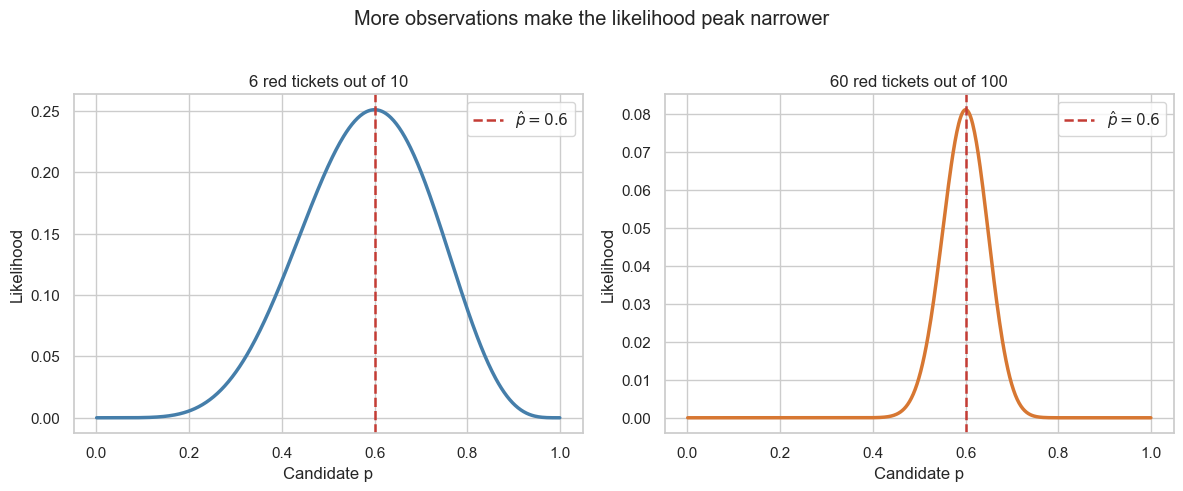

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
for ax, (total_count, red_count, color) in zip(
    axes,
    [(10, 6, "#457eaa"), (100, 60, "#d77732")],
):
    likelihood_values = np.array([
        likelihood(p, red_count, total_count) for p in p_grid
    ])
    ax.plot(p_grid, likelihood_values, color=color, linewidth=2.5)
    ax.axvline(0.6, color="#c43c35", linewidth=1.8, linestyle="--", label=r"$\hat p = 0.6$")
    ax.set(
        xlabel="Candidate p",
        ylabel="Likelihood",
        title=f"{red_count} red tickets out of {total_count}",
    )
    ax.legend()

fig.suptitle("More observations make the likelihood peak narrower", y=1.02)
plt.tight_layout()
plt.show()

## 5. Bridge to logistic regression

The ticket model assumes that every draw has the same red-ticket probability $p$. In logistic regression, each observation can have a different probability because its features differ:

$$
p_i = P(y_i=1\mid\mathbf{x}_i)
= \sigma(\mathbf{x}_i^\mathsf{T}\boldsymbol{\beta}).
$$

The likelihood idea is unchanged: choose the model parameters that make the observed binary labels most likely. In the next lecture, we will learn how to perform that optimization.

[← Return to Classification](index.qmd)